<a href="https://colab.research.google.com/github/guilherme-campagnoli/computer-vision/blob/master/2026_2_PPGIa_VCAP_Project_Guilherme_Campagnoli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Report - Computer Vision and Deep Learning

**Important**: this report may be written in either **Portuguese or English**. However, the selected language must be used consistently throughout the entire report. Mixing Portuguese and English is not allowed.

## Graduate Program in Informatics (PPGIa) / PUCPR (2026-2)

**Prof. Rayson Laroca**

`Place your name here` - `and your email here`

`Place your name here` - `and your email here`

`Place your name here` - `and your email here`

# Import the libs you need

In [ ]:
# Import all packages you need here
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# Add others as needed (sklearn, Keras/TensorFlow/PyTorch, etc.)

In [ ]:
# Fix para Google Drive
import sys
!{sys.executable} -m pip install requests beautifulsoup4
%pip install -U gdown requests


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 kB 694.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.3 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: gdown
    Found existing installation: gdown 5.2.2
    Uninstalling gdown-5.2.2:
      Successfully uninstalled gdown-5.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


# 1. Define the task and dataset

In this section:
- Clearly define the chosen task;
- Provide a description and link to the dataset;
- Justify your choice and ensure dataset is archived for final submission;
- If task ≠ image classification (detection, segmentation, OCR, etc.), explain how you will simplify Step 6 (traditional baseline).

I have choose an open dataset provided by Oxfor-IIIT Pet Dataset. This dataset is available at https://www.robots.ox.ac.uk/~vgg/data/pets/.

It contains 37 categories with around 200 images for each class. There are images from dogs and cat with different breeds.

This dataset contains annotation of:
1. Species and breed name;
2. Bounding box (ROI) around the head of the animal;
3. Foreground-background segmentation (Trimap).

![Dataset Annotations](https://www.robots.ox.ac.uk/~vgg/data/pets/pet_annotations.jpg)

In a total of 7349 images, where 4978 are dogs and 2371 are cats. The annotations also split into 25 dog breeds and 12 cats breeds.

The authors suggested to make a split like: 50% train/validation and 50% test.

From the 50% of train/validation, that is around 3680 images, I will use a *Stratified Split* to garantee that all 37 class will have a proportional quantity during the train/validation phases.

The original zip file does not contains an separate folder to train and test split, thats why we have to do it by ourself.

In [ ]:
# use as many code and text cells as needed

# 2. Acquire the dataset

In this section, **load the dataset** and carry out **initial processing** to ensure that data types are properly formatted for subsequent steps. The exact procedure may vary depending on how the data is acquired (e.g., directly from files or through well-known APIs) and also on how further steps will be conducted.

**Important note**: if the dataset is excessively large or contains high-resolution images, **consider subsampling and/or resizing the images to a manageable size** to ensure computational feasibility — especially when using limited resources such as Google Colab.

* Clearly justify the chosen subsampling strategy and confirm that the resulting data remains representative of the original dataset;
* *This subsampling step may be conducted after "Dataset analysis and visualization" if you find it more adequate*.

In [ ]:
import os
import urllib.request
import tarfile
from pathlib import PurePosixPath

# Diretório principal do dataset no Colab
DATA_DIR = "/content/oxford_pets"

# Arquivos compactados e conteúdo extraído
ARCHIVES_DIR = os.path.join(DATA_DIR, "archives")
IMAGES_DIR = os.path.join(DATA_DIR, "images")
ANNOTATIONS_DIR = os.path.join(DATA_DIR, "annotations")

# Criar os diretórios.
# exist_ok=True permite executar novamente sem erro.
os.makedirs(ARCHIVES_DIR, exist_ok=True)
os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(ANNOTATIONS_DIR, exist_ok=True)

print(f"Dataset:    {DATA_DIR}")
print(f"Compactados: {ARCHIVES_DIR}")
print(f"Imagens:    {IMAGES_DIR}")
print(f"Anotações:  {ANNOTATIONS_DIR}")

Dataset:    /content/oxford_pets
Compactados: /content/oxford_pets/archives
Imagens:    /content/oxford_pets/images
Anotações:  /content/oxford_pets/annotations


In [ ]:
def download_file(url, filename):
    filepath = os.path.join(ARCHIVES_DIR, filename)
    temporary_path = filepath + ".part"

    # Evitar repetir um download já concluído
    if os.path.isfile(filepath):
        print(f"Arquivo já disponível: {filename}")
        return

    print(f"Baixando {filename}...")

    try:
        urllib.request.urlretrieve(url, temporary_path)

        # Renomear apenas depois que o download terminar
        os.replace(temporary_path, filepath)

    except Exception:
        # Remover o download incompleto em caso de erro
        if os.path.exists(temporary_path):
            os.remove(temporary_path)

        raise

    size_mb = os.path.getsize(filepath) / (1024 ** 2)
    print(f"Download concluído: {filename} ({size_mb:.2f} MB)")

In [ ]:
IMAGES_URL = (
    #"https://thor.robots.ox.ac.uk/~vgg/data/pets/images.tar.gz"
    "https://drive.google.com/file/d/10c3zqpvFlws5AIsNG6xMLfddI41kyFt-/view?usp=sharing"
)

ANNOTATIONS_URL = (
    #"https://thor.robots.ox.ac.uk/~vgg/data/pets/annotations.tar.gz"
    "https://drive.google.com/file/d/1Gr80u0uFxTb51tDJtnQvgC63yHOqiVCp/view?usp=sharing"   #cópia de segurança
)

download_file(IMAGES_URL, "images.tar.gz")
download_file(ANNOTATIONS_URL, "annotations.tar.gz")

Baixando images.tar.gz...


Downloading...
From (original): https://drive.google.com/uc?id=10c3zqpvFlws5AIsNG6xMLfddI41kyFt-
From (redirected): https://drive.google.com/uc?id=10c3zqpvFlws5AIsNG6xMLfddI41kyFt-&confirm=t&uuid=a1c7fa29-5173-4a7e-99c8-97c8e21d069c
To: /content/archives/images.tar.gz.part
100%|██████████| 792M/792M [00:12<00:00, 65.9MB/s]


Download concluído: images.tar.gz (755.23 MB)
Baixando annotations.tar.gz...


Downloading...
From (original): https://drive.google.com/uc?id=1Gr80u0uFxTb51tDJtnQvgC63yHOqiVCp
From (redirected): https://drive.google.com/uc?id=1Gr80u0uFxTb51tDJtnQvgC63yHOqiVCp&confirm=t&uuid=2d20e6ad-8742-465a-8b99-a90a0e287667
To: /content/archives/annotations.tar.gz.part
100%|██████████| 19.2M/19.2M [00:00<00:00, 60.2MB/s]

Download concluído: annotations.tar.gz (18.28 MB)


'archives/annotations.tar.gz'

In [ ]:
def extract_archive(filename, expected_folder):
    archive_path = os.path.join(ARCHIVES_DIR, filename)

    print(f"Extraindo {filename}...")

    with tarfile.open(archive_path, "r:gz") as archive:
        members = archive.getmembers()

        # Validar todas as entradas antes da extração
        for member in members:
            path = PurePosixPath(member.name)

            if (
                path.is_absolute()
                or ".." in path.parts
                or not path.parts
                or path.parts[0] != expected_folder
            ):
                raise ValueError(
                    f"Caminho inesperado: {member.name}"
                )

            # Não permitir links ou outros tipos especiais
            if not (member.isfile() or member.isdir()):
                raise ValueError(
                    f"Entrada não permitida: {member.name}"
                )

        archive.extractall(DATA_DIR, members=members)

    print(f"Extração concluída: {expected_folder}")

In [ ]:
extract_archive("images.tar.gz", "images")
extract_archive("annotations.tar.gz", "annotations")

Extraindo images.tar.gz...


/tmp/ipykernel_3063/2065845448.py:29: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  archive.extractall(DATA_DIR, members=members)


Extração concluída: images
Extraindo annotations.tar.gz...
Extração concluída: annotations


In [ ]:
import os
import pandas as pd

def read_annotations(filename):
    # Ler a lista que define o conjunto de imagens
    filepath = os.path.join(ANNOTATIONS_DIR, filename)

    df = pd.read_csv(
        filepath,
        sep=r"\s+",
        comment="#",
        header=None,
        names=["image_name", "class_id", "species", "breed_id"]
    )

    # Montar o caminho da imagem, sem mover o arquivo original
    df["filepath"] = df["image_name"].apply(
        lambda name: os.path.join(IMAGES_DIR, name + ".jpg")
    )

    # Converter as classes de 1–37 para 0–36
    df["label"] = df["class_id"] - 1

    return df

In [ ]:
# Carregar os dois conjuntos definidos pelos autores
trainval_df = read_annotations("trainval.txt")
test_df = read_annotations("test.txt")

print(f"Treino + validação: {len(trainval_df)} imagens")
print(f"Teste: {len(test_df)} imagens")

trainval_df.head()

Treino + validação: 3680 imagens
Teste: 3669 imagens


,image_name,class_id,species,breed_id,filepath,label
0,Abyssinian_100,1,1,1,/content/oxford_pets/images/Abyssinian_100.jpg,0
1,Abyssinian_101,1,1,1,/content/oxford_pets/images/Abyssinian_101.jpg,0
2,Abyssinian_102,1,1,1,/content/oxford_pets/images/Abyssinian_102.jpg,0
3,Abyssinian_103,1,1,1,/content/oxford_pets/images/Abyssinian_103.jpg,0
4,Abyssinian_104,1,1,1,/content/oxford_pets/images/Abyssinian_104.jpg,0


# 3. Dataset analysis and visualization

In this section, you should conduct a comprehensive analysis of the dataset, reporting on (but not limited to) the following aspects:

- **Basic statistics:**
  - Total number of images;
  - Range and distribution of image resolutions;
  - Number of classes.

- **Class distribution:**
  - Visualize with plots/histograms;
  - Discuss potential **impacts of class imbalance** on model performance (e.g., bias toward majority classes).

- **Examples:**
  - Display representative samples from each class to illustrate dataset diversity and possible challenges (e.g., intra-class variation, inter-class similarity).

- **Dataset splits:**
  - If train/validation/test splits are already defined by the dataset authors, clearly describe them;
  - If not, proceed to the next section (Step 4) where you will define and justify your splitting strategy.

- **Data quality assessment:**
  - Comment on factors such as blur, occlusions, illumination issues, noise, and mislabeled or ambiguous samples;
  - Relate these observations to the **specific problem** being addressed (e.g., misclassification due to low resolution, object detection under motion blur, OCR legibility, etc.).

In [ ]:
import os
import numpy as np
import pandas as pd
import cv2

from PIL import Image
from matplotlib import pyplot as plt
from IPython.display import display

SEED = 123

# Identificar de qual conjunto oficial cada imagem veio
metadata_df = pd.concat([
    trainval_df.assign(split="Train + validation"),
    test_df.assign(split="Test")
], ignore_index=True)

# Remover apenas o número final para recuperar o nome da raça.
# Exemplo: english_cocker_spaniel_123 -> english_cocker_spaniel
metadata_df["class_name"] = metadata_df["image_name"].str.rsplit(
    "_",
    n=1
).str[0]

print(f"Total de imagens nas listas: {len(metadata_df)}")
print(f"Número de classes: {metadata_df['label'].nunique()}")

display(metadata_df.head())

Total de imagens nas listas: 7349
Número de classes: 37


,image_name,class_id,species,breed_id,filepath,label,split,class_name
0,Abyssinian_100,1,1,1,/content/oxford_pets/images/Abyssinian_100.jpg,0,Train + validation,Abyssinian
1,Abyssinian_101,1,1,1,/content/oxford_pets/images/Abyssinian_101.jpg,0,Train + validation,Abyssinian
2,Abyssinian_102,1,1,1,/content/oxford_pets/images/Abyssinian_102.jpg,0,Train + validation,Abyssinian
3,Abyssinian_103,1,1,1,/content/oxford_pets/images/Abyssinian_103.jpg,0,Train + validation,Abyssinian
4,Abyssinian_104,1,1,1,/content/oxford_pets/images/Abyssinian_104.jpg,0,Train + validation,Abyssinian


In [ ]:
# Cada rótulo deve corresponder a um único nome de raça
names_per_label = metadata_df.groupby("label")["class_name"].nunique()

assert names_per_label.eq(1).all(), \
    "Foi encontrado um rótulo associado a mais de uma raça."

assert set(metadata_df["label"]) == set(range(37)), \
    "Os rótulos não correspondem às 37 classes esperadas."

# Guardar os nomes na ordem dos rótulos
class_names = (
    metadata_df[["label", "class_name"]]
    .drop_duplicates()
    .sort_values("label")["class_name"]
    .tolist()
)

print("Mapeamento entre rótulos e classes:")

for label, name in enumerate(class_names):
    print(f"{label:2d}: {name}")

Mapeamento entre rótulos e classes:
 0: Abyssinian
 1: american_bulldog
 2: american_pit_bull_terrier
 3: basset_hound
 4: beagle
 5: Bengal
 6: Birman
 7: Bombay
 8: boxer
 9: British_Shorthair
10: chihuahua
11: Egyptian_Mau
12: english_cocker_spaniel
13: english_setter
14: german_shorthaired
15: great_pyrenees
16: havanese
17: japanese_chin
18: keeshond
19: leonberger
20: Maine_Coon
21: miniature_pinscher
22: newfoundland
23: Persian
24: pomeranian
25: pug
26: Ragdoll
27: Russian_Blue
28: saint_bernard
29: samoyed
30: scottish_terrier
31: shiba_inu
32: Siamese
33: Sphynx
34: staffordshire_bull_terrier
35: wheaten_terrier
36: yorkshire_terrier


In [ ]:
# Contar as imagens por raça e conjunto oficial
class_counts = (
    metadata_df.groupby(["class_name", "split"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Train + validation", "Test"], fill_value=0)
)

class_counts["Total"] = (
    class_counts["Train + validation"] + class_counts["Test"]
)

class_counts["Percentage (%)"] = (
    100 * class_counts["Total"] / class_counts["Total"].sum()
).round(2)

display(class_counts)

print(f"Menor quantidade por classe: {class_counts['Total'].min()}")
print(f"Maior quantidade por classe: {class_counts['Total'].max()}")

split,Train + validation,Test,Total,Percentage (%)
class_name,,,,
Abyssinian,100,98,198,2.69
Bengal,100,100,200,2.72
Birman,100,100,200,2.72
Bombay,96,88,184,2.50
British_Shorthair,100,100,200,2.72
Egyptian_Mau,93,97,190,2.59
Maine_Coon,100,100,200,2.72
Persian,100,100,200,2.72
Ragdoll,100,100,200,2.72


Menor quantidade por classe: 184
Maior quantidade por classe: 200


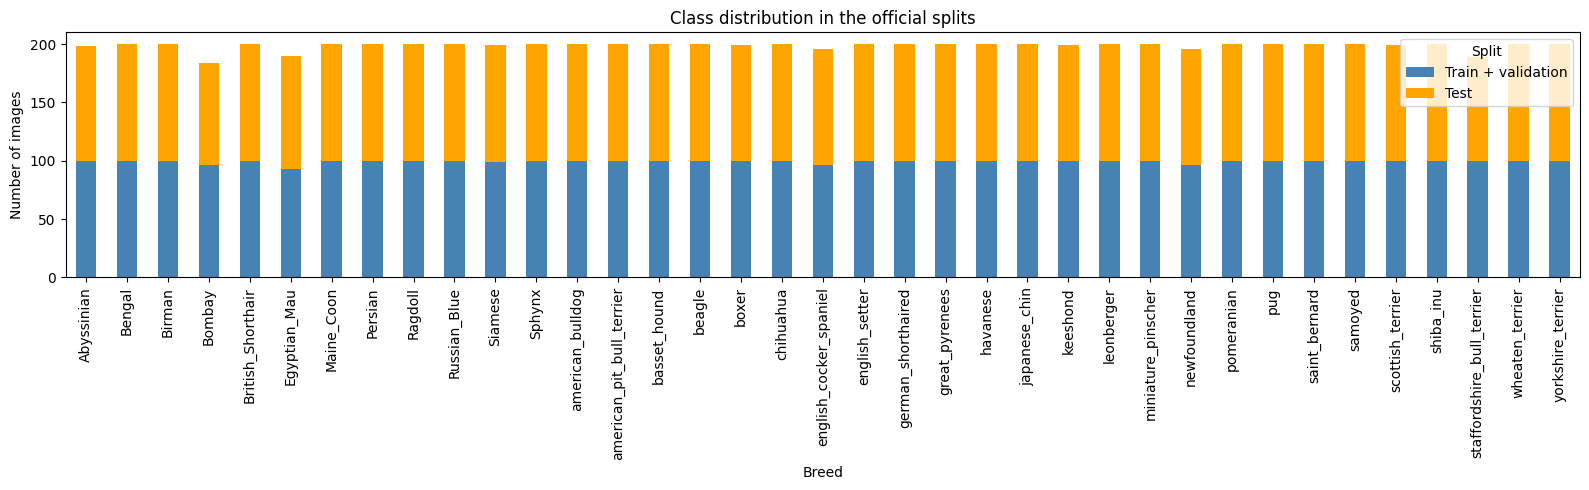

In [ ]:
ax = class_counts[["Train + validation", "Test"]].plot(
    kind="bar",
    stacked=True,
    figsize=(16, 5),
    color=["steelblue", "orange"]
)

ax.set_title("Class distribution in the official splits")
ax.set_xlabel("Breed")
ax.set_ylabel("Number of images")

plt.xticks(rotation=90)
plt.legend(title="Split")
plt.tight_layout()
plt.show()

#Dimensões e integridade


In [ ]:
def inspect_image(filepath):
    info = {
        "width": np.nan,
        "height": np.nan,
        "format": None,
        "mode": None,
        "valid": False,
        "error": None
    }

    try:
        with Image.open(filepath) as img:
            info["width"], info["height"] = img.size
            info["format"] = img.format
            info["mode"] = img.mode

            # Carregar os pixels para verificar a decodificação
            img.load()

            info["valid"] = True

    except Exception as error:
        info["error"] = f"{type(error).__name__}: {error}"

    return info

In [ ]:
image_info = []

# Processar uma imagem por vez, sem guardar todos os pixels na memória
for index, filepath in enumerate(metadata_df["filepath"], start=1):
    image_info.append(inspect_image(filepath))

    if index % 1000 == 0:
        print(f"Inspecionadas: {index}/{len(metadata_df)}")

image_info_df = pd.DataFrame(image_info)

# Criar uma nova tabela para permitir reexecutar a célula
# sem duplicar colunas em metadata_df
analysis_df = pd.concat([
    metadata_df.reset_index(drop=True),
    image_info_df
], axis=1)

valid_df = analysis_df[analysis_df["valid"]].copy()
invalid_df = analysis_df[~analysis_df["valid"]].copy()

print()
print(f"Imagens decodificadas: {len(valid_df)}")
print(f"Imagens com erro: {len(invalid_df)}")

if not invalid_df.empty:
    display(invalid_df[[
        "image_name", "split", "class_name", "error"
    ]])

Inspecionadas: 1000/7349
Inspecionadas: 2000/7349
Inspecionadas: 3000/7349
Inspecionadas: 4000/7349
Inspecionadas: 5000/7349
Inspecionadas: 6000/7349
Inspecionadas: 7000/7349

Imagens decodificadas: 7349
Imagens com erro: 0


In [ ]:
valid_df["aspect_ratio"] = valid_df["width"] / valid_df["height"]

print("Estatísticas das dimensões:")
display(
    valid_df[["width", "height", "aspect_ratio"]]
    .describe()
    .round(2)
)

print("Formatos encontrados:")
display(valid_df["format"].value_counts().rename("Images").to_frame())

print("Modos de cor encontrados:")
display(valid_df["mode"].value_counts().rename("Images").to_frame())

Estatísticas das dimensões:


,width,height,aspect_ratio
count,7349.00,7349.00,7349.00
mean,437.24,391.39,1.17
std,115.78,109.39,0.33
min,114.00,103.00,0.42
25%,337.00,333.00,0.75
50%,500.00,375.00,1.33
75%,500.00,500.00,1.49
max,3264.00,2606.00,2.56


Formatos encontrados:


,Images
format,
JPEG,7345
PNG,4


Modos de cor encontrados:


,Images
mode,
RGB,7346
RGBA,3


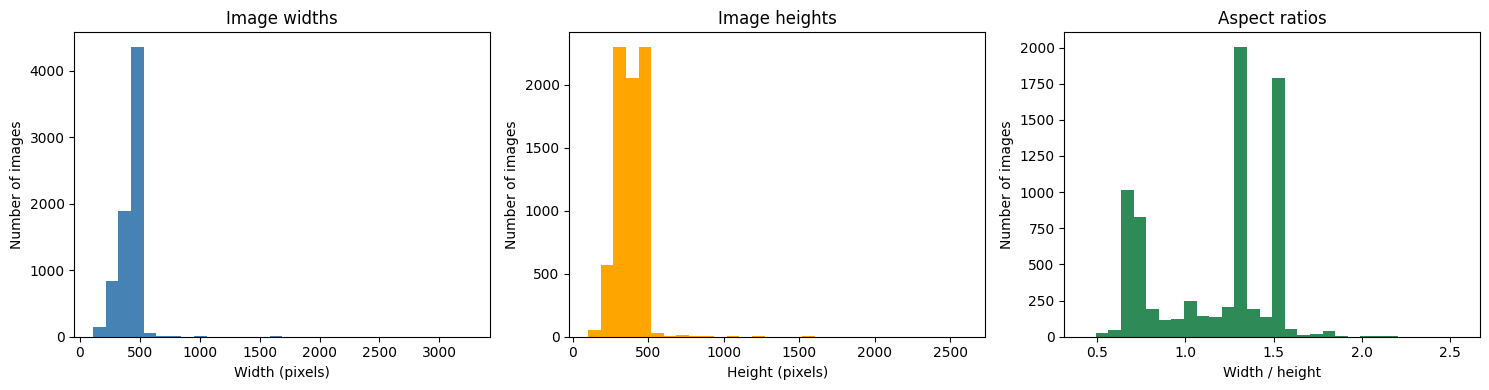

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(valid_df["width"], bins=30, color="steelblue")
axes[0].set_title("Image widths")
axes[0].set_xlabel("Width (pixels)")
axes[0].set_ylabel("Number of images")

axes[1].hist(valid_df["height"], bins=30, color="orange")
axes[1].set_title("Image heights")
axes[1].set_xlabel("Height (pixels)")
axes[1].set_ylabel("Number of images")

axes[2].hist(valid_df["aspect_ratio"], bins=30, color="seagreen")
axes[2].set_title("Aspect ratios")
axes[2].set_xlabel("Width / height")
axes[2].set_ylabel("Number of images")

plt.tight_layout()
plt.show()

Célula de código — Função de visualização

In [ ]:
def show_samples(df, title, columns=4):
    rows = int(np.ceil(len(df) / columns))

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(columns * 3.5, rows * 3),
        squeeze=False
    )

    for ax in axes.ravel():
        ax.axis("off")

    for ax, (_, sample) in zip(axes.ravel(), df.iterrows()):
        with Image.open(sample["filepath"]) as img:
            ax.imshow(img.convert("RGB"))

        ax.set_title(
            sample["class_name"].replace("_", " "),
            fontsize=10
        )

    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

Célula de código — Um exemplo por raça

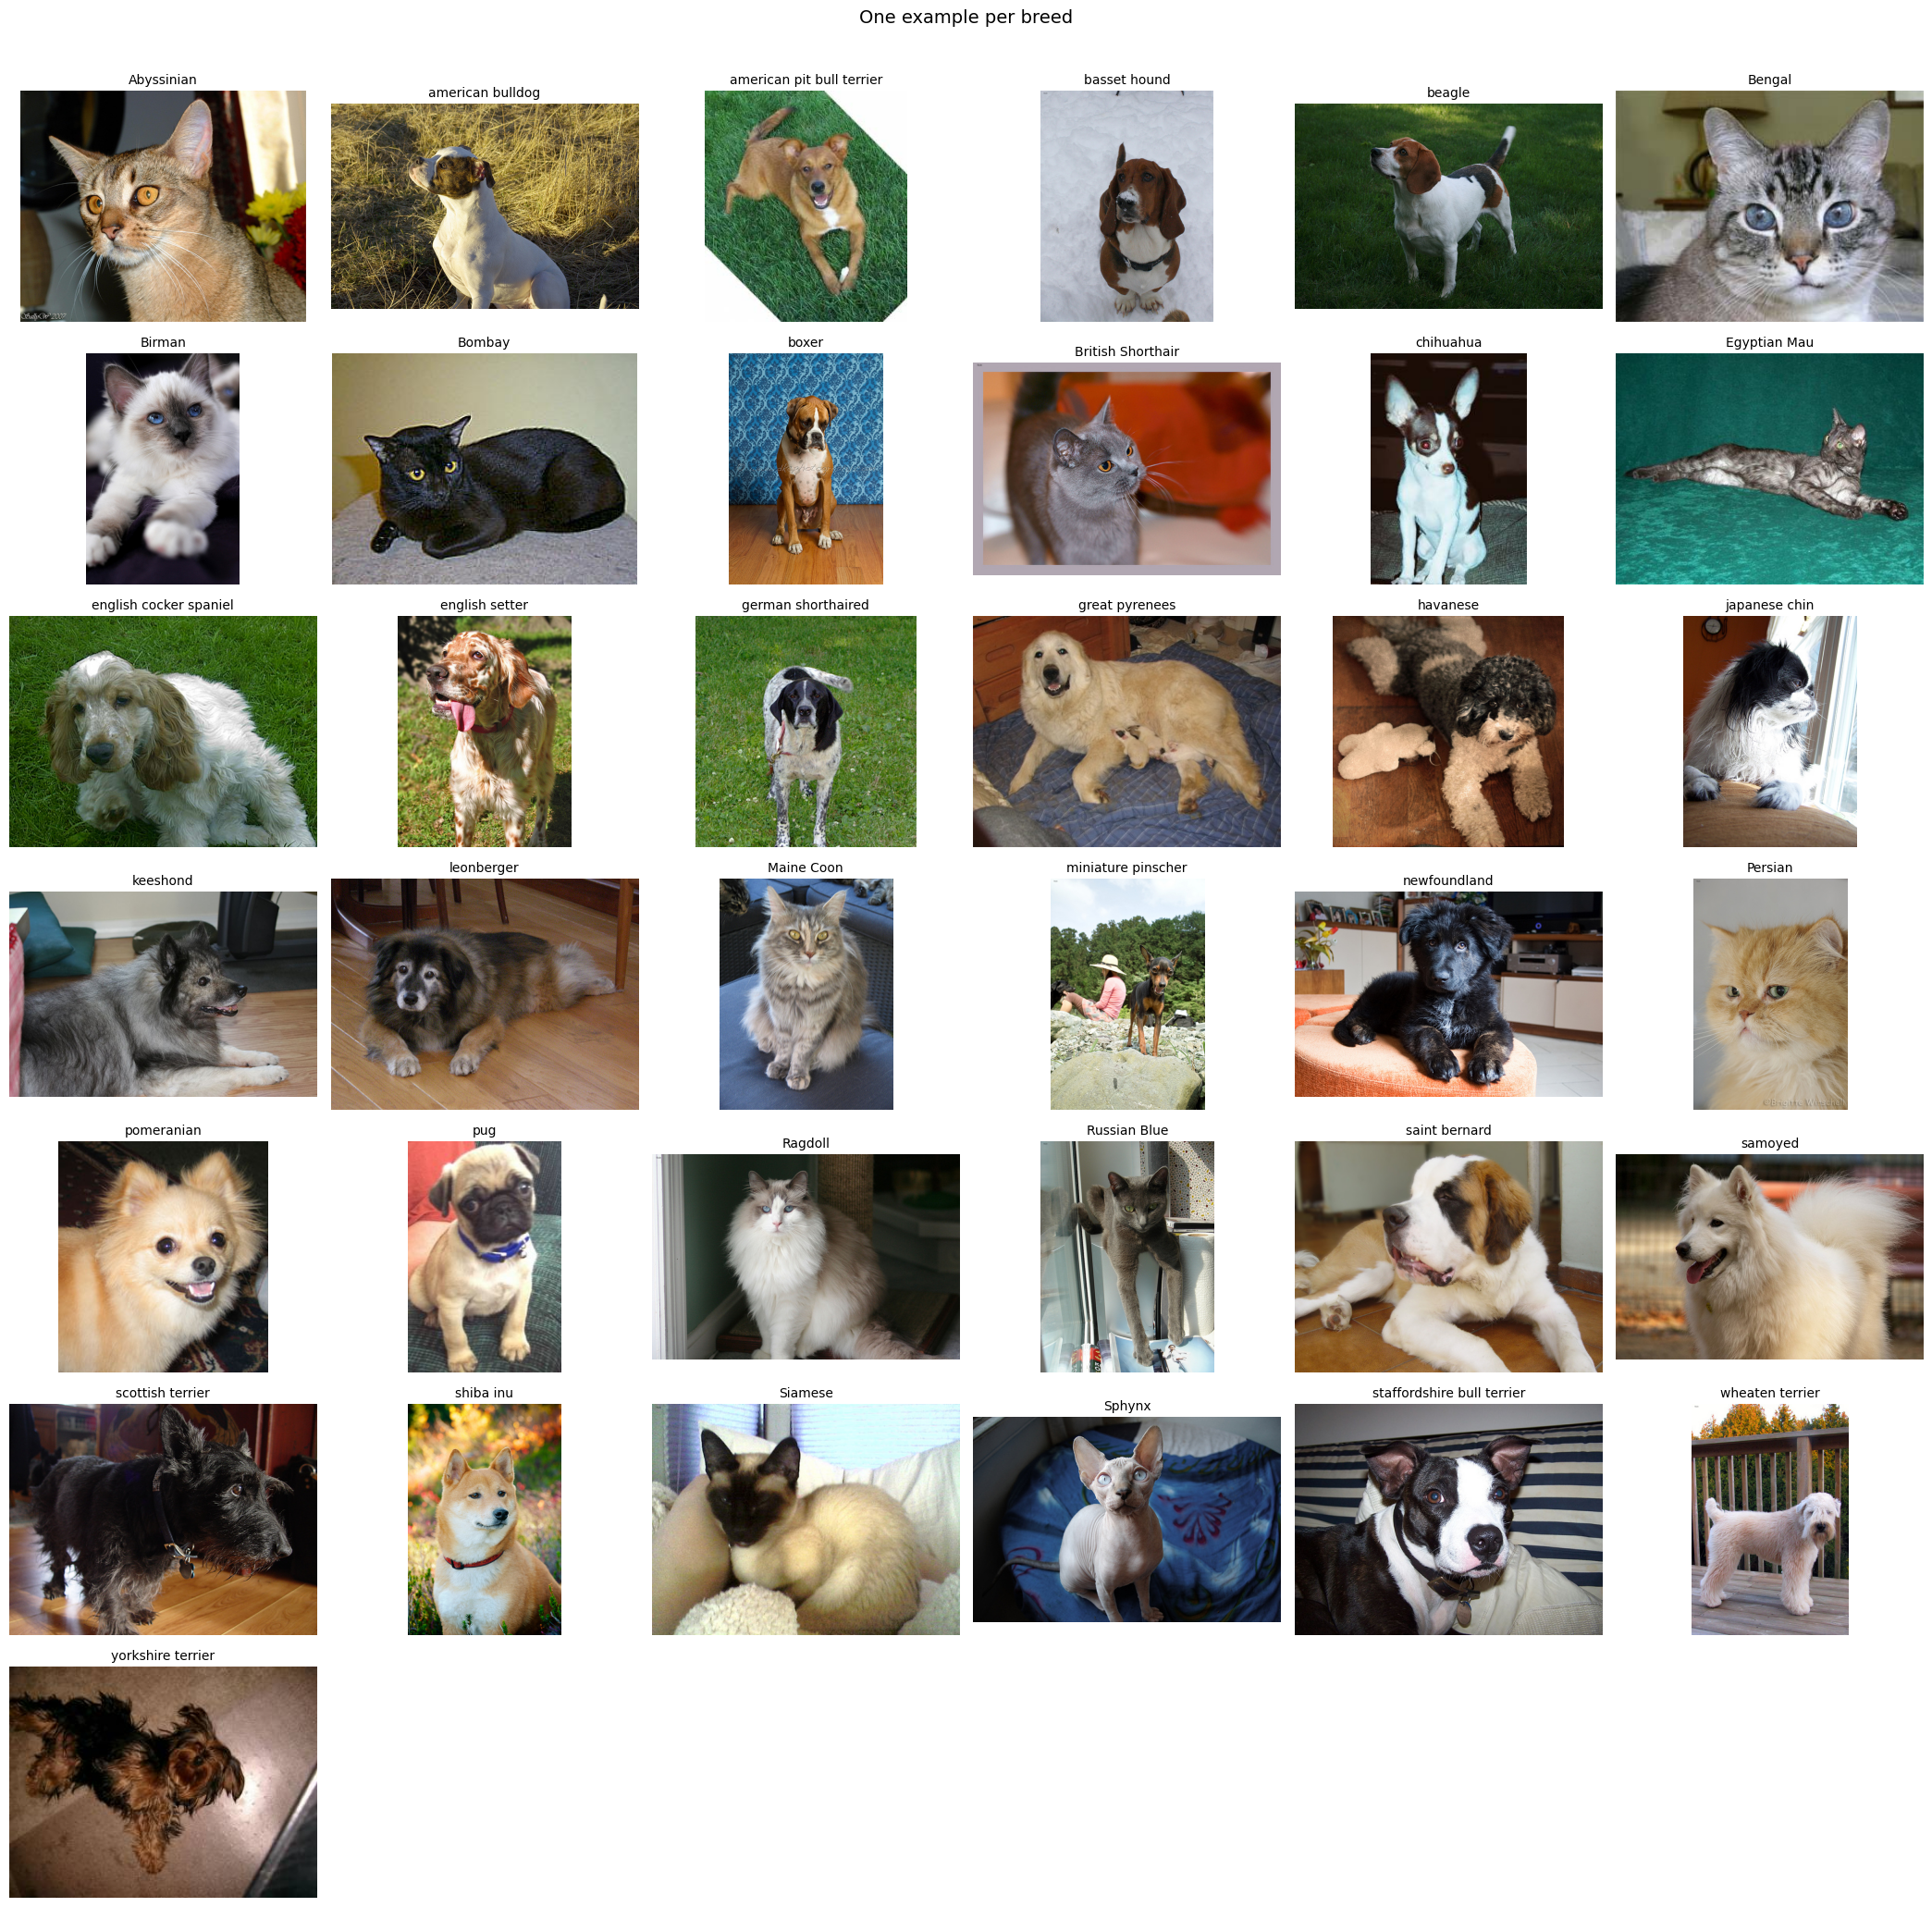

In [ ]:
exploration_df = valid_df[
    valid_df["split"] == "Train + validation"
].copy()

# Selecionar um exemplo reproduzível de cada classe
samples = (
    exploration_df.groupby("label", group_keys=False)
    .sample(n=1, random_state=SEED)
    .sort_values("label")
)

show_samples(
    samples,
    title="One example per breed",
    columns=6
)

Célula de código — Variação dentro da classe

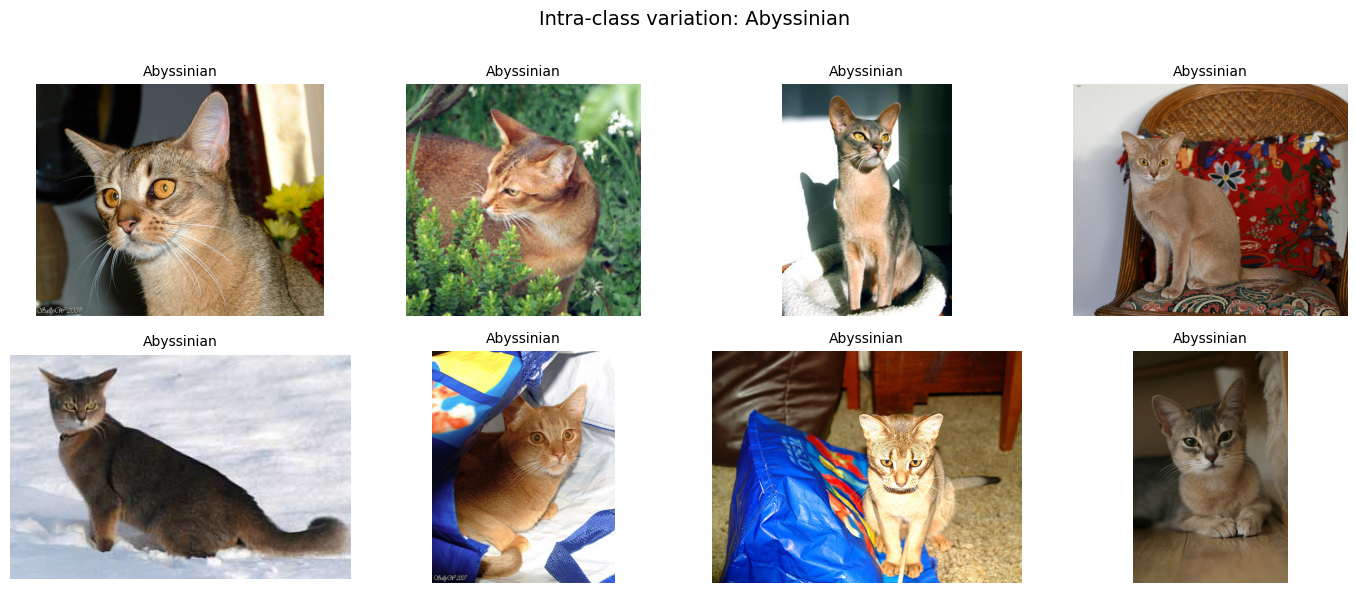

In [ ]:
# Escolher uma raça para examinar diferentes poses,
# fundos, enquadramentos e condições de iluminação
SELECTED_CLASS = "Abyssinian"

class_samples = exploration_df[
    exploration_df["class_name"] == SELECTED_CLASS
].sample(n=8, random_state=SEED)

show_samples(
    class_samples,
    title=f"Intra-class variation: {SELECTED_CLASS}",
    columns=4
)

Célula de código — Imagens com proporções extremas

,image_name,class_name,width,height,aspect_ratio
2986,Persian_162,Persian,258,500,0.516000
2833,leonberger_18,leonberger,263,500,0.526000
1844,yorkshire_terrier_144,yorkshire_terrier,163,300,0.543333
114,american_pit_bull_terrier_113,american_pit_bull_terrier,164,300,0.546667
1874,Abyssinian_175,Abyssinian,600,234,2.564103
2864,Maine_Coon_192,Maine_Coon,500,229,2.183406
267,Bengal_116,Bengal,500,230,2.173913
2806,leonberger_165,leonberger,500,240,2.083333


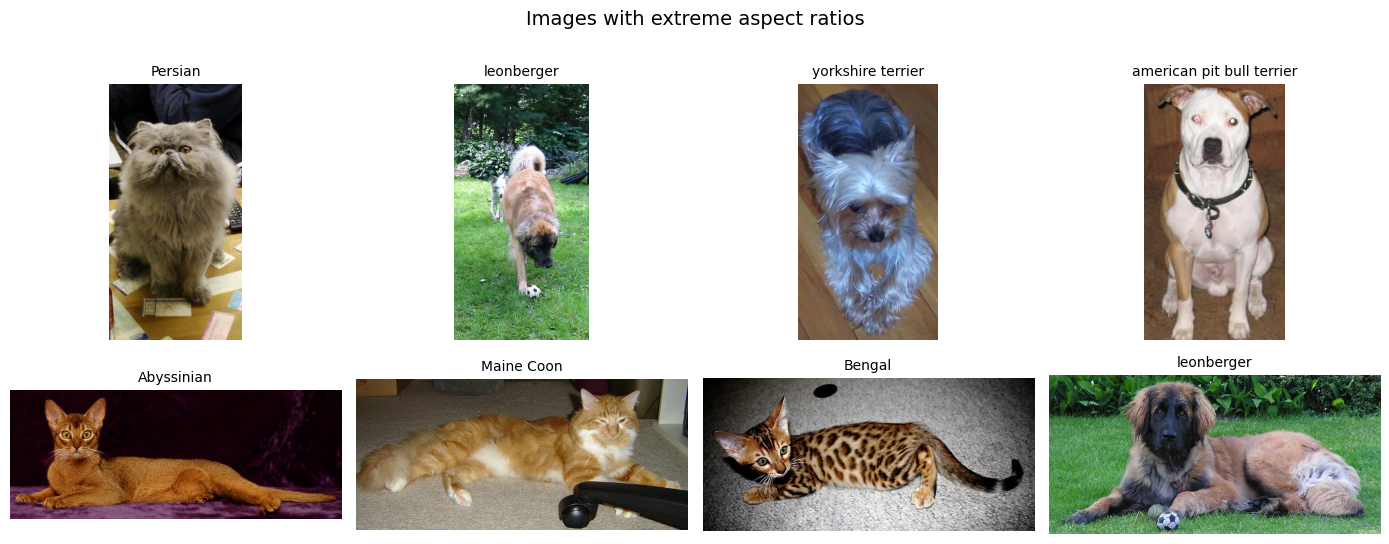

In [ ]:
# Selecionar imagens muito altas ou muito largas.
# Elas são candidatas à inspeção, não necessariamente erros.
extreme_samples = pd.concat([
    exploration_df.nsmallest(4, "aspect_ratio"),
    exploration_df.nlargest(4, "aspect_ratio")
]).drop_duplicates("image_name")

display(extreme_samples[[
    "image_name", "class_name", "width", "height", "aspect_ratio"
]])

show_samples(
    extreme_samples,
    title="Images with extreme aspect ratios",
    columns=4
)

#Explicar:

Diferenças de pose, iluminação e enquadramento dentro de uma raça.

Semelhanças visuais entre raças distintas.

Presença de fundo complexo, oclusão ou desfoque.

Modos de cor e dimensões que precisarão ser padronizados.

Quantidade e natureza dos erros de leitura, caso existam.

# 4. Dataset splitting

In this section, you should split the dataset using the division provided by the dataset authors or the one widely adopted by the research community, if such a standard exists.

If no predefined split is available, you must create your own training, validation, and test subsets. In this case, carefully select a splitting strategy that aligns with both the nature of your task and the characteristics of the dataset. **Be sure to explicitly explain and justify your reasoning**, making clear why your chosen approach is appropriate.

In [ ]:
from sklearn.model_selection import train_test_split

SEED = 123

# Reservar 20% do conjunto trainval para validação
train_df, val_df = train_test_split(
    trainval_df,
    test_size=0.20,
    stratify=trainval_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Treinamento: {len(train_df)} imagens")
print(f"Validação: {len(val_df)} imagens")
print(f"Teste: {len(test_df)} imagens")

# 5. Image Preprocessing

In this stage, you should apply preprocessing techniques tailored to your task. Start with fundamental steps such as resizing, padding, and format conversion to ensure consistency across the dataset.

Depending on the characteristics of your data and the requirements of the task, you may also consider additional techniques, such as normalization or scaling of pixel values, color space transformations (e.g., RGB to grayscale or HSV), contrast and brightness adjustment, noise reduction or filtering, among others.

When deciding which strategies to adopt, **take into account the nature of the task, the characteristics of the dataset, the computational limitations of the hardware, and the specific models or approaches you plan to use**. Explicitly explain and justify your choices, making clear why each preprocessing step is appropriate in your context.

In [ ]:
# use as many code and text cells as needed

# 6. Traditional approach

In this section, you should implement a baseline solution using **traditional image processing and machine learning techniques**.

Begin by extracting [handcrafted] features with classical methods that are suitable for your task, such as color histograms, texture descriptors (e.g., LBP), or gradient-based features (e.g., HOG).
*   You are encouraged to search for and experiment with other  descriptors from the literature that may be more relevant to your dataset or problem.

To improve robustness, consider combining multiple feature types through concatenation or feature fusion. Apply feature scaling or normalization where appropriate to ensure compatibility with the chosen classifiers.

Next, train at least two different traditional classifiers (e.g., SVM, Random Forest, KNN) on the extracted features and evaluate their performance using relevant metrics for your task. Perform an **ablation study** by comparing the results obtained with different feature sets (individually and in combination) to better understand their contribution to performance.

Naturally, provide a clear justification for each design choice, explaining why it is appropriate for your specific problem. Also, analyze and discuss the results in detail, highlighting patterns, strengths, and limitations, as well as insights gained from the ablation study.

In [ ]:
# use as many code and text cells as needed

# 7. Data augmentation

In this section, you should **design a data augmentation strategy** to increase both the diversity and robustness of your training data. Consider applying a variety of techniques, including but not limited to:

- Color adjustments  
- Rotation and scaling  
- Horizontal/vertical flipping  
- Blurring (e.g., Gaussian or motion blur)  
- Additive noise  
- Compression artifacts  
- Geometric distortions (e.g., perspective or warping)  
- Cropping  

You are encouraged to explore specialized libraries such as **Albumentations**, which provide efficient and flexible augmentation pipelines.  

Clearly specify whether augmentation will be applied **offline** (pre-generated before training) or **online** (generated dynamically during training). When dealing with class imbalance, adopt **targeted augmentation strategies** to increase the representation of minority classes.  

Make sure to **justify** your design choices. Discuss how each selected augmentation technique relates to the **requirements of the task** and the **characteristics of the dataset**, highlighting why your decisions are appropriate.

In [ ]:
# use as many code and text cells as needed

# 8. Deep learning approach

In this section, you should leverage **deep learning models** to address your task. You may explore one or both of the following strategies:

1. **Training from scratch** – train a neural network architecture directly on your dataset;  
2. **Transfer learning** – leverage pre-trained models, either by:
   - Freezing the feature extractor and training only the classifier layers; or
   - Performing fine-tuning, updating some or all pre-trained layers.

Consider well-established model families such as EfficientNet, MobileNet, ResNet, VGG, and [efficient] Transformer-based architectures, choosing those most appropriate given your **task requirements** and **computational constraints**.  

To optimize performance, experiment with key hyperparameters (e.g., optimizer, initial learning rate, batch size) and incorporate adaptive training techniques, such as:  
- Learning rate schedulers (e.g., *ReduceLROnPlateau*);
- Early stopping mechanisms to prevent overfitting.

You must train **at least two distinct models** and evaluate their performance using **relevant quantitative metrics**. Compare the outcomes with the best-performing traditional approach (from Step 6). Additionally, include **qualitative analysis** (e.g., visualization of predictions, error inspection, or case studies) to better understand model behavior beyond numerical results.

Whenever possible, conduct an **ablation study** to isolate the contribution of specific design choices (e.g., augmentation strategy, training from scratch vs. transfer learning, etc.) to justify your final pipeline.

In [ ]:
# use as many code and text cells as needed

# Digest

In this section, you should **briefly summarize the main findings** of your project. Additionally, provide a **critical reflection** on your work and the effort invested throughout the module. Highlight the aspects you believe were handled successfully, as well as those that, in hindsight, you would approach differently.

As part of this reflection, consider whether the outcomes and lessons learned from this project contribute meaningfully to your overall **academic development** and to your **readiness for professional or postgraduate pursuits after graduation**.

This digest is **mandatory**, but **will not be considered in the formal evaluation or affect your grade**.

```
Add your text here.
```

# Final Steps (Submission)

1. Save the complete report (including all steps from Step 1 onward) as a Jupyter Notebook (`.ipynb`), ensuring that all code cells are executed and their outputs are visible in the exported notebook;
2. Export a copy of the report as a PDF file (`.pdf`), ensuring that all code cells are executed and their outputs are visible in the exported document. If the generated PDF has formatting issues, include it in the submission anyway;
3. Compress the Jupyter Notebook and PDF files into a single ZIP archive named `EquipeXX.zip`, replacing XX with your team number;
4. Upload the ZIP file to Canvas.